# FER2013 — Architecture 1: MLP baseline

## 1. Setup

In [30]:

import os, random, time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import wandb

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

DATA_DIR = "data"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
NUM_CLASSES = len(EMOTIONS)

Using device: mps


## 2. Data loading & splits

In [43]:
df = pd.read_csv(f"{DATA_DIR}/icml_face_data.csv")
df.columns = [c.strip() for c in df.columns]

def pixels_to_array(frame):
    X = np.stack([np.asarray(p.split(), dtype=np.uint8) for p in frame["pixels"]])
    return X.reshape(-1, 48, 48)

train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

X_train = pixels_to_array(train_df); y_train = train_df["emotion"].to_numpy()
X_val   = pixels_to_array(val_df);   y_val   = val_df["emotion"].to_numpy()
X_test  = pixels_to_array(test_df);  y_test  = test_df["emotion"].to_numpy()

MEAN = float(X_train.mean() / 255.0)
STD  = float(X_train.std()  / 255.0)
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"normalized mean/std (train): {MEAN:.4f} / {STD:.4f}")

counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = counts.sum() / (NUM_CLASSES * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
for i, e in enumerate(EMOTIONS):
    print(f"{e:9s} n={counts[i]:5d}  weight={class_weights[i]:.2f}")

train (28709, 48, 48)  val (3589, 48, 48)  test (3589, 48, 48)
normalized mean/std (train): 0.5077 / 0.2550
Angry     n= 3995  weight=1.03
Disgust   n=  436  weight=9.41
Fear      n= 4097  weight=1.00
Happy     n= 7215  weight=0.57
Sad       n= 4830  weight=0.85
Surprise  n= 3171  weight=1.29
Neutral   n= 4965  weight=0.83


## 3. Dataset & transforms

In [44]:
class FER2013Dataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomResizedCrop(48, scale=(0.85, 1.0), antialias=True),
        ])
        self.normalize = transforms.Normalize(mean=[MEAN], std=[STD])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).float().div(255.0).unsqueeze(0)
        if self.augment:
            img = self.aug(img)
        return self.normalize(img), self.y[idx]


def make_loaders(batch_size=64, augment=True, num_workers=0,
                 pin_memory=None, persistent_workers=None):
    tr = FER2013Dataset(X_train, y_train, augment=augment)
    va = FER2013Dataset(X_val,   y_val,   augment=False)
    te = FER2013Dataset(X_test,  y_test,  augment=False)
    if pin_memory is None:
        pin_memory = (device.type == "cuda")
    if persistent_workers is None:
        persistent_workers = num_workers > 0
    common = dict(batch_size=batch_size, num_workers=num_workers,
                  pin_memory=pin_memory, persistent_workers=persistent_workers)
    return (DataLoader(tr, shuffle=True,  **common),
            DataLoader(va, shuffle=False, **common),
            DataLoader(te, shuffle=False, **common))

## 4. Wandb login

In [45]:
import getpass

WANDB_PROJECT = "fer2013-emotion"
WANDB_ENTITY  = None

if not os.environ.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = getpass.getpass("Paste your W&B API key (from https://wandb.ai/authorize): ").strip()

wandb.login()

True

True

## 5. Training engine

In [46]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return {"loss": total_loss / n, "acc": correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    preds_all, true_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        n += xb.size(0)
        preds_all.append(preds.cpu())
        true_all.append(yb.cpu())
    preds = torch.cat(preds_all).numpy()
    true  = torch.cat(true_all).numpy()
    return {"loss": total_loss / n,
            "acc": correct / n,
            "f1_macro": f1_score(true, preds, average="macro"),
            "preds": preds, "true": true}

## 6. Sanity checks

In [47]:
import math

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def forward_check(build_model):
    model = build_model().to(device)
    dummy = torch.randn(4, 1, 48, 48, device=device)
    out = model(dummy)
    assert out.shape == (4, NUM_CLASSES), f"expected (4, {NUM_CLASSES}), got {tuple(out.shape)}"
    print(f"forward OK -> logits {tuple(out.shape)},  params {count_params(model):,}")


def init_loss_check(build_model, tol=0.3):
    set_seed(SEED)
    model = build_model().to(device).eval()
    loader, _, _ = make_loaders(batch_size=512, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        loss = nn.CrossEntropyLoss()(model(xb), yb).item()
    expected = math.log(NUM_CLASSES)
    flag = "OK" if abs(loss - expected) < tol else "!! OFF"
    print(f"init loss {loss:.3f}  (expect ~{expected:.3f})  {flag}")


def overfit_one_batch(build_model, steps=200, lr=1e-3):
    set_seed(SEED)
    model = build_model().to(device)
    loader, _, _ = make_loaders(batch_size=32, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(xb).argmax(1) == yb).float().mean().item()
    print(f"overfit one batch: loss {losses[0]:.3f} -> {losses[-1]:.3f},  batch acc {acc:.1%}")
    return losses


def sanity_checks(build_model):
    forward_check(build_model)
    init_loss_check(build_model)
    overfit_one_batch(build_model)

## 7. Architecture 1 — MLP (baseline)

In [48]:

def make_activation(name="relu"):
    name = name.lower()
    table = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU,
             "gelu": nn.GELU, "tanh": nn.Tanh, "elu": nn.ELU}
    if name not in table:
        raise ValueError(f"unknown activation: {name}")
    return table[name]()


def apply_init(module, scheme="default", activation="relu"):
    if scheme == "default":
        return module
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif scheme == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif scheme == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            else:
                raise ValueError(f"unknown init scheme: {scheme}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return module

In [49]:
class MLP(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, hidden=256, activation="relu",
                 norm="none", dropout=0.0, init="default"):
        super().__init__()

        def norm_layer(dim):
            if norm == "batch": return nn.BatchNorm1d(dim)
            if norm == "layer": return nn.LayerNorm(dim)
            if norm == "none":  return nn.Identity()
            raise ValueError(f"unknown norm: {norm}")

        layers = [
            nn.Flatten(),
            nn.Linear(48 * 48, hidden),
            norm_layer(hidden),
            make_activation(activation),
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden, num_classes))

        self.net = nn.Sequential(*layers)
        apply_init(self, init, activation)

    def forward(self, x):
        return self.net(x)

In [50]:
sanity_checks(lambda: MLP())

forward OK -> logits (4, 7),  params 591,879
init loss 1.929  (expect ~1.946)  OK
overfit one batch: loss 1.924 -> 0.000,  batch acc 100.0%
forward OK -> logits (4, 7),  params 591,879
init loss 1.929  (expect ~1.946)  OK
overfit one batch: loss 1.924 -> 0.000,  batch acc 100.0%


In [56]:
def fit(build_model, arch, epochs=20, lr=1e-3, batch_size=64, augment=False,
        weight_decay=0.0, use_class_weights=True, optimizer_name="adam",
        lr_schedule="none",
        study=None, extra_config=None, run_name=None, notes="", tags=None,
        log_to_wandb=True, watch=True, verbose=True):
    set_seed(SEED)
    model = build_model().to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size=batch_size, augment=augment)

    weight = class_weights.to(device) if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")

    if lr_schedule == "none":
        scheduler = None
    elif lr_schedule == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif lr_schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif lr_schedule == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    else:
        raise ValueError(f"unknown lr_schedule: {lr_schedule}")

    config = dict(arch=arch, epochs=epochs, lr=lr, batch_size=batch_size,
                  augment=augment, weight_decay=weight_decay,
                  use_class_weights=use_class_weights, optimizer=optimizer_name,
                  lr_schedule=lr_schedule, params=count_params(model), seed=SEED)
    if extra_config:
        config.update(extra_config)

    run = None
    if log_to_wandb:
        all_tags = [arch] + (tags or []) + ([f"study:{study}"] if study else [])
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY,
            name=run_name or f"{arch}-lr{lr:g}-bs{batch_size}" + ("-aug" if augment else ""),
            group=arch,
            job_type=study or "train", config=config,
            notes=notes, tags=all_tags, reinit=True)
        if watch:
            wandb.watch(model, criterion, log="all", log_freq=100)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_acc, best_epoch, best_state = 0.0, 0, None
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["val_f1"].append(va["f1_macro"])

        if log_to_wandb:
            wandb.log({"epoch": epoch,
                       "train/loss": tr["loss"], "train/acc": tr["acc"],
                       "val/loss": va["loss"], "val/acc": va["acc"],
                       "val/f1_macro": va["f1_macro"],
                       "gap/acc": tr["acc"] - va["acc"],
                       "gap/loss": va["loss"] - tr["loss"],
                       "lr": optimizer.param_groups[0]["lr"]})

        if va["acc"] > best_val_acc:
            best_val_acc, best_epoch = va["acc"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"[{arch}] epoch {epoch:02d}/{epochs}  "
                  f"train_loss {tr['loss']:.3f} acc {tr['acc']:.3f} | "
                  f"val_loss {va['loss']:.3f} acc {va['acc']:.3f} f1 {va['f1_macro']:.3f}")

        if scheduler is not None:
            scheduler.step(va["acc"]) if lr_schedule == "plateau" else scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)
    te = evaluate(model, test_loader, criterion)
    history["best_val_acc"], history["best_epoch"] = best_val_acc, best_epoch
    history["test_acc"], history["test_f1"] = te["acc"], te["f1_macro"]
    print(f"[{arch}] best val acc {best_val_acc:.3f} @ epoch {best_epoch}  |  "
          f"TEST acc {te['acc']:.3f}  f1 {te['f1_macro']:.3f}")

    if log_to_wandb:
        run.summary["best_val_acc"] = best_val_acc
        run.summary["best_epoch"]   = best_epoch
        run.summary["test_acc"]     = te["acc"]
        run.summary["test_f1_macro"] = te["f1_macro"]
        run.summary["test_loss"]    = te["loss"]
        wandb.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=te["true"], preds=te["preds"], class_names=EMOTIONS)})
        run.finish()
    return model, history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title} — loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
    ax2.set_title(f"{title} — accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

[MLP] epoch 01/20  train_loss 1.856 acc 0.289 | val_loss 1.753 acc 0.301 f1 0.253
[MLP] epoch 02/20  train_loss 1.700 acc 0.344 | val_loss 1.736 acc 0.348 f1 0.312
[MLP] epoch 03/20  train_loss 1.625 acc 0.378 | val_loss 1.687 acc 0.352 f1 0.311
[MLP] epoch 04/20  train_loss 1.556 acc 0.397 | val_loss 1.634 acc 0.380 f1 0.339
[MLP] epoch 05/20  train_loss 1.480 acc 0.422 | val_loss 1.685 acc 0.380 f1 0.352
[MLP] epoch 06/20  train_loss 1.416 acc 0.449 | val_loss 1.695 acc 0.382 f1 0.356
[MLP] epoch 07/20  train_loss 1.367 acc 0.464 | val_loss 1.752 acc 0.394 f1 0.371
[MLP] epoch 08/20  train_loss 1.301 acc 0.483 | val_loss 1.732 acc 0.401 f1 0.372
[MLP] epoch 09/20  train_loss 1.252 acc 0.502 | val_loss 1.747 acc 0.407 f1 0.372
[MLP] epoch 10/20  train_loss 1.193 acc 0.520 | val_loss 1.896 acc 0.403 f1 0.369
[MLP] epoch 11/20  train_loss 1.137 acc 0.543 | val_loss 1.892 acc 0.403 f1 0.382
[MLP] epoch 12/20  train_loss 1.088 acc 0.561 | val_loss 1.910 acc 0.404 f1 0.371
[MLP] epoch 13/2

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▁▂▂▂▃▃▃▃▄▅▅▆▆▇▆▇▇██
gap/loss,▁▂▂▂▂▃▃▃▃▄▄▅▅▇▆▆█▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▁▁
val/acc,▁▄▄▆▆▆▇▇█▇▇▇▅▆▅▇▇██▇
val/f1_macro,▁▄▄▅▆▆▇▇▇▇▇▇▅▆▆▇▇███
val/loss,▂▂▁▁▁▁▂▂▂▃▃▃▄█▅▅█▆▆▇
best_epoch,18
best_val_acc,0.41404


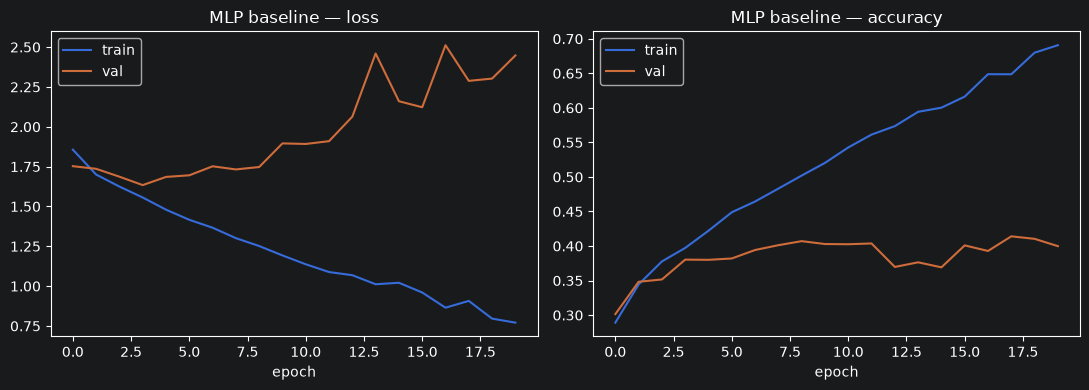

[MLP] epoch 01/20  train_loss 1.856 acc 0.289 | val_loss 1.753 acc 0.301 f1 0.253
[MLP] epoch 02/20  train_loss 1.700 acc 0.344 | val_loss 1.736 acc 0.348 f1 0.312
[MLP] epoch 03/20  train_loss 1.625 acc 0.378 | val_loss 1.687 acc 0.352 f1 0.311
[MLP] epoch 04/20  train_loss 1.556 acc 0.397 | val_loss 1.634 acc 0.380 f1 0.339
[MLP] epoch 05/20  train_loss 1.480 acc 0.422 | val_loss 1.685 acc 0.380 f1 0.352
[MLP] epoch 06/20  train_loss 1.416 acc 0.449 | val_loss 1.695 acc 0.382 f1 0.356
[MLP] epoch 07/20  train_loss 1.367 acc 0.464 | val_loss 1.752 acc 0.394 f1 0.371
[MLP] epoch 08/20  train_loss 1.301 acc 0.483 | val_loss 1.732 acc 0.401 f1 0.372
[MLP] epoch 09/20  train_loss 1.252 acc 0.502 | val_loss 1.747 acc 0.407 f1 0.372
[MLP] epoch 10/20  train_loss 1.193 acc 0.520 | val_loss 1.896 acc 0.403 f1 0.369
[MLP] epoch 11/20  train_loss 1.137 acc 0.543 | val_loss 1.892 acc 0.403 f1 0.382
[MLP] epoch 12/20  train_loss 1.088 acc 0.561 | val_loss 1.910 acc 0.404 f1 0.371
[MLP] epoch 13/2

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▁▂▂▂▃▃▃▃▄▅▅▆▆▇▆▇▇██
gap/loss,▁▂▂▂▂▃▃▃▃▄▄▅▅▇▆▆█▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▁▁
val/acc,▁▄▄▆▆▆▇▇█▇▇▇▅▆▅▇▇██▇
val/f1_macro,▁▄▄▅▆▆▇▇▇▇▇▇▅▆▆▇▇███
val/loss,▂▂▁▁▁▁▂▂▂▃▃▃▄█▅▅█▆▆▇
best_epoch,18
best_val_acc,0.41404


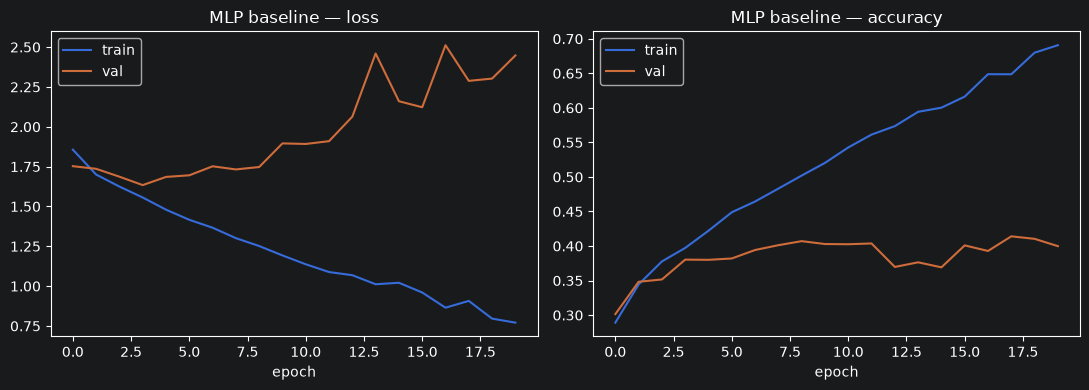

In [52]:
mlp_model, mlp_hist = fit(lambda: MLP(), arch="MLP", epochs=20, lr=1e-3, augment=False,
                          notes="Flatten + 1 hidden layer. Baseline / floor.")

plot_history(mlp_hist, title="MLP baseline")

### Study 1 — Optimizer (Adam vs SGD vs RMSProp)

In [53]:
opt_results = {}
for opt in ["adam", "sgd", "rmsprop"]:
    _, hist = fit(lambda: MLP(), arch="MLP", epochs=20, lr=1e-3, augment=False,
                  optimizer_name=opt, study="optimizer",
                  run_name=f"MLP-opt={opt}",
                  notes=f"Optimizer study: {opt} at lr=1e-3.",
                  watch=False)
    opt_results[opt] = hist

pd.DataFrame({o: {"best_val_acc": round(h["best_val_acc"], 4),
                  "best_epoch":   h["best_epoch"],
                  "test_acc":     round(h["test_acc"], 4),
                  "test_f1":      round(h["test_f1"], 4)}
             for o, h in opt_results.items()}).T

[MLP] epoch 01/20  train_loss 1.856 acc 0.289 | val_loss 1.753 acc 0.301 f1 0.253
[MLP] epoch 02/20  train_loss 1.700 acc 0.344 | val_loss 1.736 acc 0.348 f1 0.312
[MLP] epoch 03/20  train_loss 1.625 acc 0.378 | val_loss 1.687 acc 0.352 f1 0.311
[MLP] epoch 04/20  train_loss 1.556 acc 0.397 | val_loss 1.634 acc 0.380 f1 0.339
[MLP] epoch 05/20  train_loss 1.480 acc 0.422 | val_loss 1.685 acc 0.380 f1 0.352
[MLP] epoch 06/20  train_loss 1.416 acc 0.449 | val_loss 1.695 acc 0.382 f1 0.356
[MLP] epoch 07/20  train_loss 1.367 acc 0.464 | val_loss 1.752 acc 0.394 f1 0.371
[MLP] epoch 08/20  train_loss 1.301 acc 0.483 | val_loss 1.732 acc 0.401 f1 0.372
[MLP] epoch 09/20  train_loss 1.252 acc 0.502 | val_loss 1.747 acc 0.407 f1 0.372
[MLP] epoch 10/20  train_loss 1.193 acc 0.520 | val_loss 1.896 acc 0.403 f1 0.369
[MLP] epoch 11/20  train_loss 1.137 acc 0.543 | val_loss 1.892 acc 0.403 f1 0.382
[MLP] epoch 12/20  train_loss 1.088 acc 0.561 | val_loss 1.910 acc 0.404 f1 0.371
[MLP] epoch 13/2

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▁▂▂▂▃▃▃▃▄▅▅▆▆▇▆▇▇██
gap/loss,▁▂▂▂▂▃▃▃▃▄▄▅▅▇▆▆█▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▁▁
val/acc,▁▄▄▆▆▆▇▇█▇▇▇▅▆▅▇▇██▇
val/f1_macro,▁▄▄▅▆▆▇▇▇▇▇▇▅▆▆▇▇███
val/loss,▂▂▁▁▁▁▂▂▂▃▃▃▄█▅▅█▆▆▇
best_epoch,18
best_val_acc,0.41404


[MLP] epoch 01/20  train_loss 1.821 acc 0.266 | val_loss 1.743 acc 0.325 f1 0.280
[MLP] epoch 02/20  train_loss 1.706 acc 0.331 | val_loss 1.705 acc 0.354 f1 0.314
[MLP] epoch 03/20  train_loss 1.646 acc 0.358 | val_loss 1.654 acc 0.368 f1 0.331
[MLP] epoch 04/20  train_loss 1.590 acc 0.378 | val_loss 1.628 acc 0.371 f1 0.326
[MLP] epoch 05/20  train_loss 1.541 acc 0.394 | val_loss 1.634 acc 0.355 f1 0.319
[MLP] epoch 06/20  train_loss 1.499 acc 0.403 | val_loss 1.602 acc 0.368 f1 0.329
[MLP] epoch 07/20  train_loss 1.450 acc 0.420 | val_loss 1.622 acc 0.381 f1 0.356
[MLP] epoch 08/20  train_loss 1.407 acc 0.433 | val_loss 1.600 acc 0.391 f1 0.360
[MLP] epoch 09/20  train_loss 1.371 acc 0.446 | val_loss 1.602 acc 0.384 f1 0.344
[MLP] epoch 10/20  train_loss 1.327 acc 0.458 | val_loss 1.626 acc 0.374 f1 0.335
[MLP] epoch 11/20  train_loss 1.293 acc 0.473 | val_loss 1.590 acc 0.411 f1 0.378
[MLP] epoch 12/20  train_loss 1.256 acc 0.488 | val_loss 1.601 acc 0.402 f1 0.367
[MLP] epoch 13/2

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▂▃▃▄▄▄▄▅▅▅▆▆▆▆▇▇▇██
gap/loss,▁▂▂▂▃▃▃▃▄▄▄▅▅▆▆▆▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇███
train/loss,█▇▆▆▆▅▅▄▄▄▃▃▃▃▂▂▂▁▁▁
val/acc,▁▃▄▄▃▄▅▆▅▅▇▇▆▆█▇▇██▇
val/f1_macro,▁▃▄▄▃▄▅▅▅▄▇▆▆▆█▇▇██▇
val/loss,█▆▄▃▃▂▂▁▂▃▁▂▃▄▂▃▅▄▄█
best_epoch,18
best_val_acc,0.42129


[MLP] epoch 01/20  train_loss 9.103 acc 0.174 | val_loss 4.435 acc 0.130 f1 0.126
[MLP] epoch 02/20  train_loss 4.972 acc 0.152 | val_loss 4.062 acc 0.208 f1 0.170
[MLP] epoch 03/20  train_loss 4.834 acc 0.177 | val_loss 5.694 acc 0.183 f1 0.161
[MLP] epoch 04/20  train_loss 5.050 acc 0.162 | val_loss 6.009 acc 0.202 f1 0.182
[MLP] epoch 05/20  train_loss 5.008 acc 0.158 | val_loss 6.628 acc 0.157 f1 0.162
[MLP] epoch 06/20  train_loss 4.978 acc 0.183 | val_loss 4.553 acc 0.132 f1 0.150
[MLP] epoch 07/20  train_loss 4.660 acc 0.161 | val_loss 4.072 acc 0.134 f1 0.143
[MLP] epoch 08/20  train_loss 4.827 acc 0.165 | val_loss 5.470 acc 0.182 f1 0.184
[MLP] epoch 09/20  train_loss 4.816 acc 0.203 | val_loss 4.254 acc 0.170 f1 0.154
[MLP] epoch 10/20  train_loss 4.874 acc 0.178 | val_loss 3.522 acc 0.153 f1 0.161
[MLP] epoch 11/20  train_loss 4.906 acc 0.192 | val_loss 6.674 acc 0.154 f1 0.162
[MLP] epoch 12/20  train_loss 4.726 acc 0.219 | val_loss 3.790 acc 0.162 f1 0.164
[MLP] epoch 13/2

...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▂▃▃▄▄▄▄▅▅▅▆▆▆▆▇▇▇██
gap/loss,▁▂▂▂▃▃▃▃▄▄▄▅▅▆▆▆▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇███
train/loss,█▇▆▆▆▅▅▄▄▄▃▃▃▃▂▂▂▁▁▁
val/acc,▁▃▄▄▃▄▅▆▅▅▇▇▆▆█▇▇██▇
val/f1_macro,▁▃▄▄▃▄▅▅▅▄▇▆▆▆█▇▇██▇
val/loss,█▆▄▃▃▂▂▁▂▃▁▂▃▄▂▃▅▄▄█
best_epoch,18
best_val_acc,0.42129


[MLP] epoch 01/20  train_loss 9.103 acc 0.174 | val_loss 4.435 acc 0.130 f1 0.126
[MLP] epoch 02/20  train_loss 4.972 acc 0.152 | val_loss 4.062 acc 0.208 f1 0.170
[MLP] epoch 03/20  train_loss 4.834 acc 0.177 | val_loss 5.694 acc 0.183 f1 0.161
[MLP] epoch 04/20  train_loss 5.050 acc 0.162 | val_loss 6.009 acc 0.202 f1 0.182
[MLP] epoch 05/20  train_loss 5.008 acc 0.158 | val_loss 6.628 acc 0.157 f1 0.162
[MLP] epoch 06/20  train_loss 4.978 acc 0.183 | val_loss 4.553 acc 0.132 f1 0.150
[MLP] epoch 07/20  train_loss 4.660 acc 0.161 | val_loss 4.072 acc 0.134 f1 0.143
[MLP] epoch 08/20  train_loss 4.827 acc 0.165 | val_loss 5.470 acc 0.182 f1 0.184
[MLP] epoch 09/20  train_loss 4.816 acc 0.203 | val_loss 4.254 acc 0.170 f1 0.154
[MLP] epoch 10/20  train_loss 4.874 acc 0.178 | val_loss 3.522 acc 0.153 f1 0.161
[MLP] epoch 11/20  train_loss 4.906 acc 0.192 | val_loss 6.674 acc 0.154 f1 0.162
[MLP] epoch 12/20  train_loss 4.726 acc 0.219 | val_loss 3.790 acc 0.162 f1 0.164
[MLP] epoch 13/2

IOStream.flush timed out


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▇▁▄▂▄▇▆▃▆▅▆▇▆▃▆▅█▂▆▂
gap/loss,▁▄▆▆▇▅▅▆▅▄▇▄▅█▇▇█▅▆▇
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▃▁▄▂▂▄▂▂▆▄▅█▅▄▆█▇██▇
train/loss,█▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂▁
val/acc,▁▆▄▅▃▁▁▄▃▂▂▃▃▅▂▆▂█▄█
val/f1_macro,▁▄▃▅▄▃▂▅▃▄▄▄▄▄▃▄▂█▄█
val/loss,▃▂▅▅▆▃▂▄▂▁▆▁▃▇▆▇█▂▃▅
best_epoch,18
best_val_acc,0.24826


,best_val_acc,best_epoch,test_acc,test_f1
adam,0.4140,18.0,0.4241,0.4121
sgd,0.4213,18.0,0.4361,0.4174
rmsprop,0.2483,18.0,0.2577,0.2145


### Study 2 — Hyper-parameter search: Grid vs Random

In [57]:
import itertools, inspect

def _split_kwargs(model_cls, cfg):
    model_params = set(inspect.signature(model_cls.__init__).parameters) - {"self"}
    model_kwargs = {k: v for k, v in cfg.items() if k in model_params}
    fit_kwargs   = {k: v for k, v in cfg.items() if k not in model_params}
    return model_kwargs, fit_kwargs


def _run_one(model_cls, arch, study, cfg):
    model_kwargs, fit_kwargs = _split_kwargs(model_cls, cfg)
    tag = "-".join(f"{k}={round(v, 5) if isinstance(v, float) else v}"
                   for k, v in cfg.items() if k not in ("epochs", "augment", "use_class_weights"))
    _, hist = fit(lambda: model_cls(**model_kwargs), arch=arch, study=study,
                  extra_config=cfg, run_name=f"{arch}-{tag}", watch=False,
                  verbose=False, **fit_kwargs)
    return {**cfg,
            "best_val_acc": round(hist["best_val_acc"], 4),
            "test_acc":     round(hist["test_acc"], 4),
            "test_f1":      round(hist["test_f1"], 4)}


def grid_search(model_cls, arch, param_grid, fixed=None, study="grid-search"):
    fixed = fixed or {}
    keys = list(param_grid)
    combos = list(itertools.product(*param_grid.values()))
    print(f"[grid] {len(combos)} combinations")
    rows = []
    for i, vals in enumerate(combos, 1):
        cfg = {**fixed, **dict(zip(keys, vals))}
        print(f"--- grid {i}/{len(combos)}: {dict(zip(keys, vals))} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)


def random_search(model_cls, arch, space, n_trials, fixed=None, study="random-search", seed=SEED):
    fixed = fixed or {}
    rng = random.Random(seed)
    rows = []
    for i in range(1, n_trials + 1):
        sample = {k: (v(rng) if callable(v) else rng.choice(v)) for k, v in space.items()}
        cfg = {**fixed, **sample}
        print(f"--- random {i}/{n_trials}: {sample} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

In [55]:
SEARCH_FIXED = dict(epochs=15, optimizer_name="adam", augment=False)

grid = {"lr": [1e-3, 5e-4], "dropout": [0.0, 0.5]}
grid_df = grid_search(MLP, arch="MLP", param_grid=grid, fixed=SEARCH_FIXED)

space = {
    "lr":         lambda r: 10 ** r.uniform(-4, -2.5),
    "dropout":    [0.0, 0.3, 0.5],
    "activation": ["relu", "gelu"],
}
rand_df = random_search(MLP, arch="MLP", space=space, n_trials=4, fixed=SEARCH_FIXED)

print("\n===== GRID results (sorted) ====="); display(grid_df)
print("\n===== RANDOM results (sorted) ====="); display(rand_df)
print(f"\nGrid   best val acc: {grid_df['best_val_acc'].iloc[0]:.4f}")
print(f"Random best val acc: {rand_df['best_val_acc'].iloc[0]:.4f}")

[grid] 4 combinations

--- grid 1/4: {'lr': 0.001, 'dropout': 0.0} ---


[MLP] epoch 01/15  train_loss 1.856 acc 0.289 | val_loss 1.753 acc 0.301 f1 0.253
[MLP] epoch 02/15  train_loss 1.700 acc 0.344 | val_loss 1.736 acc 0.348 f1 0.312
[MLP] epoch 03/15  train_loss 1.625 acc 0.378 | val_loss 1.687 acc 0.352 f1 0.311
[MLP] epoch 04/15  train_loss 1.556 acc 0.397 | val_loss 1.634 acc 0.380 f1 0.339
[MLP] epoch 05/15  train_loss 1.480 acc 0.422 | val_loss 1.685 acc 0.380 f1 0.352
[MLP] epoch 06/15  train_loss 1.416 acc 0.449 | val_loss 1.695 acc 0.382 f1 0.356
[MLP] epoch 07/15  train_loss 1.367 acc 0.464 | val_loss 1.752 acc 0.394 f1 0.371
[MLP] epoch 08/15  train_loss 1.301 acc 0.483 | val_loss 1.732 acc 0.401 f1 0.372
[MLP] epoch 09/15  train_loss 1.252 acc 0.502 | val_loss 1.747 acc 0.407 f1 0.372
[MLP] epoch 10/15  train_loss 1.193 acc 0.520 | val_loss 1.896 acc 0.403 f1 0.369
[MLP] epoch 11/15  train_loss 1.137 acc 0.543 | val_loss 1.892 acc 0.403 f1 0.382
[MLP] epoch 12/15  train_loss 1.088 acc 0.561 | val_loss 1.910 acc 0.404 f1 0.371
[MLP] epoch 13/1

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
gap/acc,▁▁▂▂▃▃▃▄▄▅▅▆▇██
gap/loss,▁▂▂▂▂▃▃▃▄▅▅▅▆█▇
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▃▄▅▅▅▆▆▇▇▇██
train/loss,█▇▆▆▅▄▄▃▃▂▂▂▁▁▁
val/acc,▁▄▄▆▆▆▇█████▆▆▅
val/f1_macro,▁▄▄▆▆▇▇▇▇▇█▇▆▆▇
val/loss,▂▂▁▁▁▂▂▂▂▃▃▃▅█▅
best_epoch,9
best_val_acc,0.40708



--- grid 2/4: {'lr': 0.001, 'dropout': 0.5} ---


[MLP] epoch 01/15  train_loss 1.988 acc 0.246 | val_loss 1.771 acc 0.315 f1 0.263
[MLP] epoch 02/15  train_loss 1.825 acc 0.283 | val_loss 1.762 acc 0.344 f1 0.302
[MLP] epoch 03/15  train_loss 1.810 acc 0.295 | val_loss 1.725 acc 0.328 f1 0.289
[MLP] epoch 04/15  train_loss 1.794 acc 0.299 | val_loss 1.718 acc 0.353 f1 0.310
[MLP] epoch 05/15  train_loss 1.770 acc 0.308 | val_loss 1.714 acc 0.331 f1 0.289
[MLP] epoch 06/15  train_loss 1.770 acc 0.310 | val_loss 1.690 acc 0.327 f1 0.293
[MLP] epoch 07/15  train_loss 1.740 acc 0.320 | val_loss 1.728 acc 0.339 f1 0.302
[MLP] epoch 08/15  train_loss 1.730 acc 0.323 | val_loss 1.666 acc 0.361 f1 0.324
[MLP] epoch 09/15  train_loss 1.712 acc 0.328 | val_loss 1.675 acc 0.347 f1 0.297
[MLP] epoch 10/15  train_loss 1.700 acc 0.330 | val_loss 1.714 acc 0.335 f1 0.297
[MLP] epoch 11/15  train_loss 1.683 acc 0.336 | val_loss 1.634 acc 0.360 f1 0.323
[MLP] epoch 12/15  train_loss 1.697 acc 0.341 | val_loss 1.664 acc 0.362 f1 0.302
[MLP] epoch 13/1

...


===== GRID results (sorted) =====


,epochs,optimizer_name,augment,lr,dropout,best_val_acc,test_acc,test_f1
0,15,adam,False,0.0005,0.0,0.4185,0.4168,0.4021
1,15,adam,False,0.0010,0.0,0.4071,0.4124,0.3781
2,15,adam,False,0.0005,0.5,0.3982,0.4110,0.3752
3,15,adam,False,0.0010,0.5,0.3826,0.3865,0.3421



===== RANDOM results (sorted) =====


,epochs,optimizer_name,augment,lr,dropout,activation,best_val_acc,test_acc,test_f1
0,15,adam,False,0.000233,0.0,relu,0.4171,0.4227,0.4024
1,15,adam,False,0.000769,0.0,relu,0.4149,0.4246,0.3948
2,15,adam,False,0.000910,0.0,gelu,0.4090,0.4177,0.3920
3,15,adam,False,0.001035,0.5,relu,0.3859,0.3915,0.3474



Grid   best val acc: 0.4185
Random best val acc: 0.4171
